# Project 4: Depth Estimation using Stereo

## Part 1: Simple stereo by matching patches

We know that there is some encoding of depth when images are captured using a stereo rig, much like human eyes.

You can try a simple experiment to see the stereo effect in action. Try seeing a scene with only your left eye. Then close your left eye and see using your right eye. Make the transition quickly. You should notice a horizontal shift in the image perceived. Can you comment on the difference in shift for different objects when you do this experiment? Is it related to the depth of the objects in some way?

In this notebook, we will generate disparity maps — maps of horizontal shifts estimated at each pixel. We will start working on a simple algorithm, which will then be evolved to give better disparity maps.

## Setup

1. Install Miniconda. It doesn’t matter whether you use Python 2 or 3 because we will create our own environment that uses 3 anyways.
2. Create a conda environment using the appropriate command. On Windows, open the installed “Conda prompt” to run the command. On MacOS and Linux, you can just use a terminal window to run the command, Modify the command based on your OS (linux, mac, or win): `conda env create -f proj4_env_<OS>.yml`
3. This should create an environment named ‘proj4’. Activate it using the Windows command, activate proj4 or the MacOS / Linux command, source activate proj4
4. Install the project package, by running `pip install -e .` inside the repo folder.
5. Run the notebook using `jupyter notebook ./proj4_code/simple_stereo.ipynb`
6. Ensure that all sanity checks are passing by running pytest inside the “unit_tests/” folder.
7. Generate the zip folder for the code portion of your submission once you’ve finished the project using `python3 zip_submission.py --uid <your_uid>` and submit to Gradescope.

## Writeup

For this project, you will answer all written questions directly within this notebook. Each section includes specific questions related to your implementation, results, and analysis.

Provide concise and well-organized explanations in the answer cells provided. Your responses should describe the logic behind your algorithm, the design decisions you made, and your observations from the results. A good writeup not only presents outputs but also discusses what they mean and why they behave as expected.

If you implement any extensions or improvements beyond the required parts, include them in the “Extra Credit” section at the end of the notebook. Ensure that all code, figures, and explanations needed for grading are included here, as this notebook will be the only file submitted to Gradescope.

## Rubric (Total: 100 pts)

- **60 pts: Code**
  - 15 pts: `generate_random_stereogram` in `utils.py`
  - 15 pts: `similarity_measures.py`
  - 30 pts: `disparity_map.py`
- **40 pts: Writeup (within notebook)**
- **−5 × n pts:** Lose 5 points for each instruction not followed for submission format or naming.

In [18]:
# Import required packages and helper functions
# Make sure you've run `pip install -e .` before executing this cell

import sys
sys.path.append('..')

from proj4_code.utils import load_image, PIL_resize, generate_random_stereogram, stereo_helper_fn
from proj4_code.disparity_map import calculate_disparity_map
from proj4_code.similarity_measures import ssd_similarity_measure, sad_similarity_measure

import torch
import numpy as np
import matplotlib.pyplot as plt

from unit_tests.test_base import verify

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We will use a helper function called `stereo_helper_fn` from `utils.py` for calculating and plotting the disparity maps using the functions you will define in this notebook.

## Random dot stereogram

It was once believed that in order to perceive depth, one must either match feature points (like SIFT) between left and right images, or rely on other visual cues such as shadows.

A *random dot stereogram* eliminates all other depth cues, proving that a stereo setup alone is sufficient to infer depth.

A random dot stereogram is generated by the following steps:

1. Create the left image with random dots at each pixel (values 0 or 1).  
2. Create the right image as a copy of the left image.  
3. Select a region in the right image and shift it horizontally.  
4. Add a random pattern in the right image to fill the empty region created after the shift.

You will implement these steps in the function `generate_random_stereogram()` in `utils.py`.  
A corresponding unit test is defined in `test_utils.py`.

Please read the documentation carefully before you begin.

### Reflection Question 1:
What is the relation between disparity map and depth?  
**Answer:** Text/Equations/Drawing — whatever you feel is relevant
- Response: The first thing to understand here is what disparity is. Disparity is defined for a single pixel in our left image. d = x - x' with x being the starting horizontal point in the left image and x' being the horizontal point in the right image that is the match. (Here we remember that when we are calculating disparity we use a window around the pixels) A disparity map is simply a grid of all disparity values for all pixels in our left image. A disparity map shows us the relative depth of each object. For example if the value in the disparity map is high (lots of distance between the two matches) we can infer that the things that appear in that window are close to the camera. If the value in the disparity map is low we can infer that the things that appear in that window are far away. This point can also be seen if we do the thumb trick we talked about in class.

In [19]:
# Generate left and right images
im_left, im_right = generate_random_stereogram(im_size=(51, 51, 3))

In [20]:
# Verify correctness of your generate_random_stereogram() implementation
from unit_tests.test_utils import test_generate_random_stereogram

print('Test for random dot stereogram:', verify(test_generate_random_stereogram))

Test for random dot stereogram: "Correct"


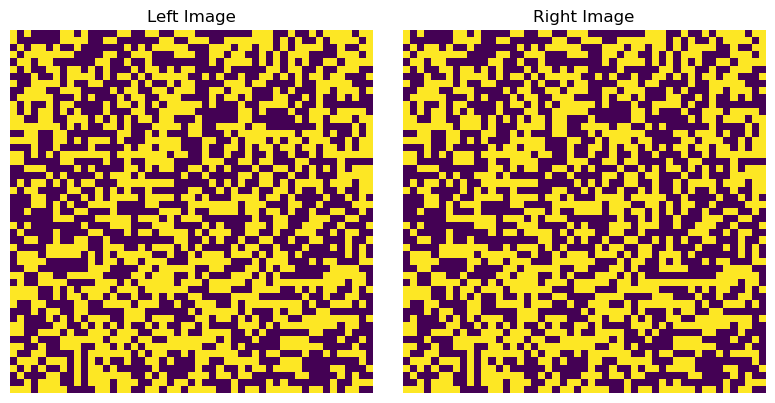

In [21]:
# Convert im_left and im_right to CPU based numpy array
im_left_np = im_left.numpy()
im_right_np = im_right.numpy()

# Visualize the generated random dot stereogram images
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(im_left_np)
plt.title('Left Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(im_right_np)
plt.title('Right Image')
plt.axis('off')

plt.tight_layout()
plt.show()

### Reflection Question 2:
Random dot stereogram image [51×51×3]: Can you judge depth by looking at them?  
**Answer:** Text here
- Response: When I look at the two images normally I am unable to judge depth. If I cross my eyes or really relax my eyes I do feel like something starts to pop out but not any particular pattern. I think that I can infer depth but because its just random pixels it isn't very useful information.

## Similarity Measure

We will use similarity functions to compare patches between the left and right images.  
You will implement two types of similarity measures:

1. **Sum of Squared Differences (SSD):**  
   $SSD(A, B) = \sum_{i,j}(A_{ij} - B_{ij})^2$
2. **Sum of Absolute Differences (SAD):**  
   $SAD(A, B) = \sum_{i,j}|A_{ij} - B_{ij}$

Implement these functions in `similarity_measures.py`.  
The corresponding unit tests are defined in `test_similarity_measures.py`.

Implement the similarity function and disparity map calculation. You will need it in the next steps

### Run Similarity Measure Tests

Use the provided unit tests to verify that your implementations of the SSD and SAD functions in `similarity_measures.py` are correct.

In [22]:
# Run unit tests for the similarity measures

from unit_tests.test_similarity_measures import (
    test_ssd_similarity_measure_values,
    test_sad_similarity_measure_values,
    test_similarity_measure_size_compatibility
)

print('Testing value for SAD measure:', verify(test_sad_similarity_measure_values))
print('Testing value for SSD measure:', verify(test_ssd_similarity_measure_values))
print('Testing input size compatibility for measures:', verify(test_similarity_measure_size_compatibility))

Testing value for SAD measure: "Correct"
Testing value for SSD measure: "Correct"
Testing input size compatibility for measures: "Correct"


## Disparity Map

We are now ready to write the code for a simple algorithm for stereo matching.

<figure>
    <img src="figures/disparity_calculation_example.jpg" width="600" title="Example of a stereo algorithm" />
    <center><figcaption align="center">Example of a stereo algorithm</figcaption></center>
</figure>

These are the steps taken in this image (and will be implemented by you):

1. Pick a patch in the left image (red block), P1.
2. Place the patch in the same (x,y) coordinates in the right image (red block). As this is binocular stereo, we will need to search for P1 on the left side starting from this position. Make sure you understand this point well before proceeding further.
4. Slide the block of candidates to the left (indicated by the different pink blocks). The search area is restricted by the parameter max_search_bound in the code. The candidates will overlap.
5. We will pick the candidate patch with the minimum similarity error (green block). The horizontal shift from the red block to the green block in this image is the disparity value for the centre of P1 in the left image.

Note: the images have already been rectified and hence we can search on just a horizontal scan line.

The function works as follows:

* Input
    1. Left image
    2. Right image
    3. Similarity function
    4. Patch size
    5. Max search value
* Output
    1. Disparity map

Implement this in `disparity_map.py` (please read the documentation carefully!). The corresponding unit tests are defined in `test_disparity_map.py`.

In [23]:
from unit_tests.test_disparity_map import (
  test_disparity_deltafn_failure,
  test_disparity_deltafn_success,
  test_disparity_map_size,
  test_disparity_random_stereogram,
  test_disparity_translation_shift
)

In [24]:
# Run unit tests for disparity map implementation
print('Testing disparity map delta function (failure case):', verify(test_disparity_deltafn_failure))
print('Testing disparity map delta function (success case):', verify(test_disparity_deltafn_success))
print('Testing disparity map size', verify(test_disparity_map_size))
print('Testing random stereogram ouptut', verify(test_disparity_random_stereogram))
print('Testing disparity on translation shift', verify(test_disparity_translation_shift))

Testing disparity map delta function (failure case): "Correct"
Testing disparity map delta function (success case): "Correct"
Testing disparity map size "Correct"
Testing random stereogram ouptut "Correct"
Testing disparity on translation shift "Correct"


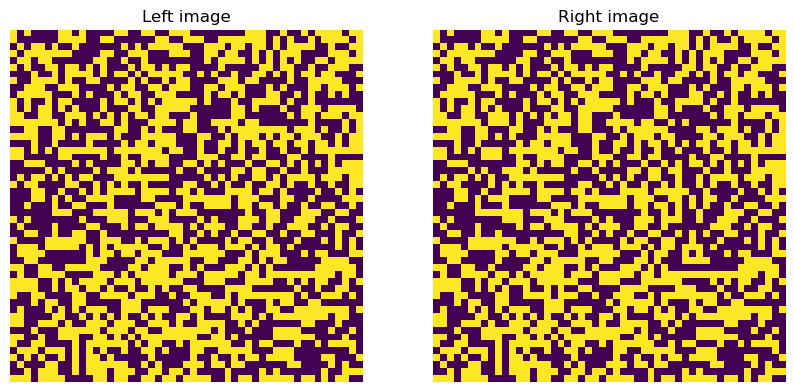

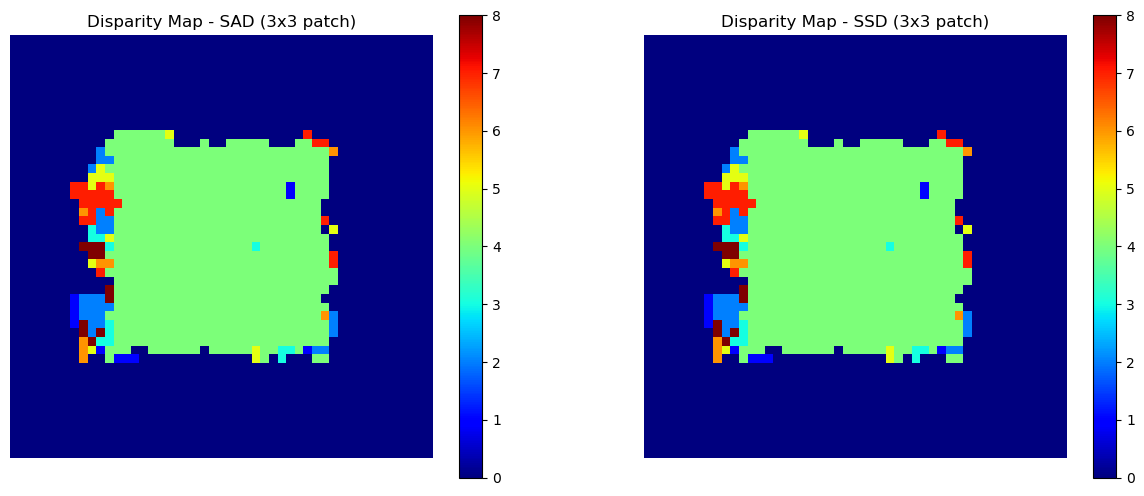

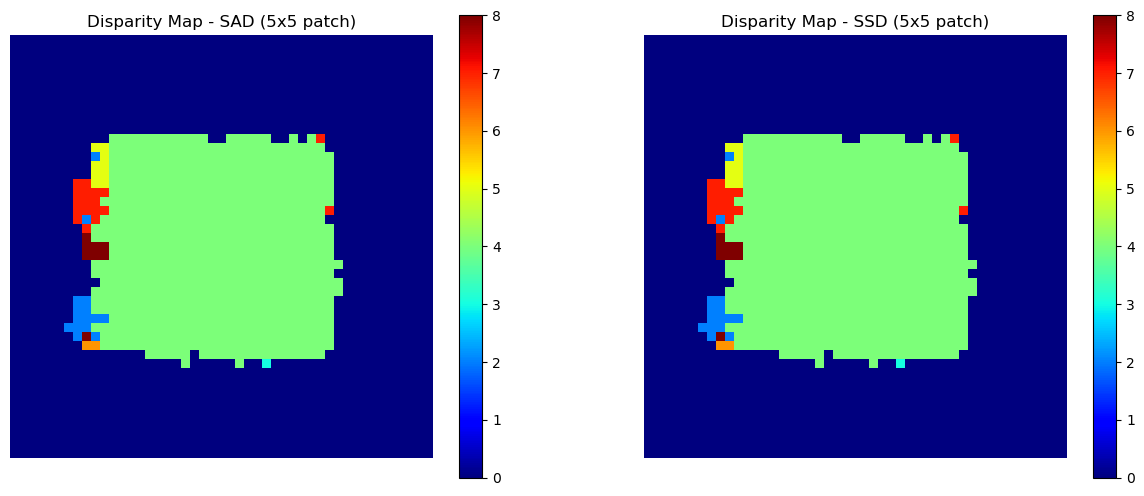

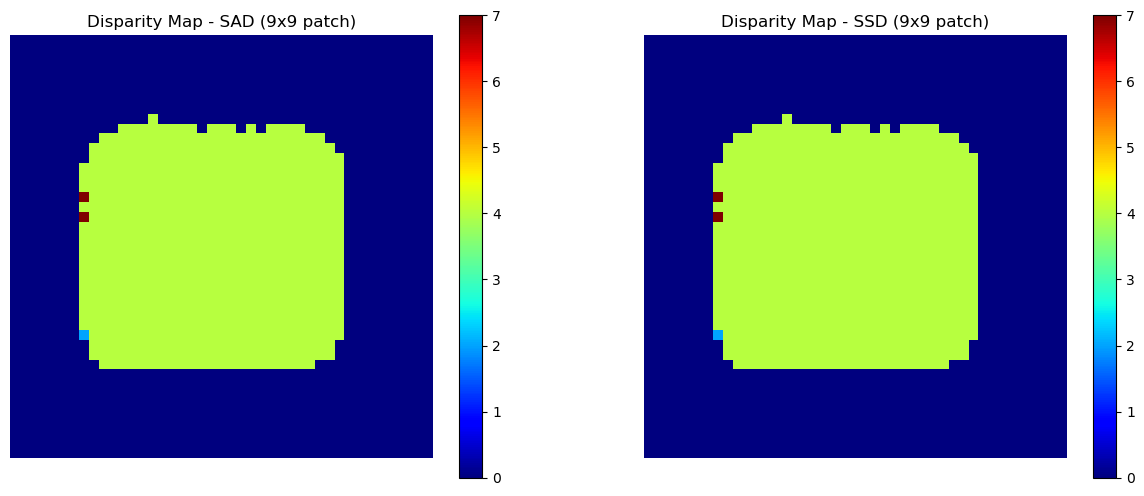

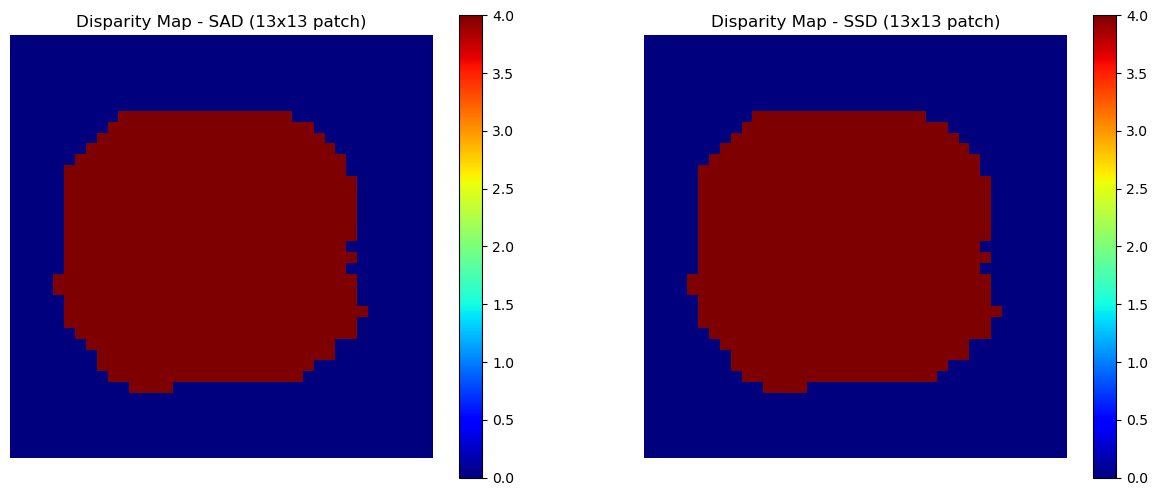

In [25]:
stereo_helper_fn(im_left, im_right, block_size = [3,5,9,13], max_search_bound=8)

### Reflection Question 3:
What is the effect of increasing the block size? Explain the reasoning behind it.  
**Answer:** Text solution here 
- Response: As we increase the block size we notice that we get more uniform disparities. For example in the 3x3 patch we have loads of different disparities. In the 13x13 we only have two types of disparities which is 4.0 or 0.0. This is because the bigger our block the less our similarity measures are able to distinguish between unique patches. In our specific case we only changed a small window of the pixels so if our window is huge our similarity measures will think there are high similarities everywhere. (The average case is that there is a match because we are taking such a large window which overpowers the small amount of change we made)

### Reflection Question 4:
Observe the random dot stereogram disparity map. Why does the left edge show poor results?  
**Answer:** Text solution here
- Response: When we created our solution we made sure that the sliding window couldn't go out of the bounds of the image. Because of this the values that are close to the bounds aren't able to really get any valuable matching data. This causes the left edge to be very noisy. 

## Error Profile Analysis

In this section, you will analyze the **similarity error profile** between patches to understand how matching quality varies with horizontal shifts.

You need to find **two examples** that display:
- A **convex error profile** (smooth, single minimum)
- A **non-convex error profile** (multiple minima)

For reference, here are example plots:

<img src="figures/convex_sample.png" width="350"/>  

**Convex Profile**

<img src="figures/non_convex_sample.png" width="350"/>  

**Non-Convex Profile**

Before computing the full disparity map, analyze the similarity error between patches in both cases.
Find regions in the image that exhibit a close-to-convex profile and another that exhibits a highly non-convex profile.

In [26]:
# Load and downsample Adirondack stereo pair
base_path = '../data/adirondack/'
im_left = PIL_resize(load_image(base_path + 'im_left.png'), (0.1, 0.1))
im_right = PIL_resize(load_image(base_path + 'im_right.png'), (0.1, 0.1))

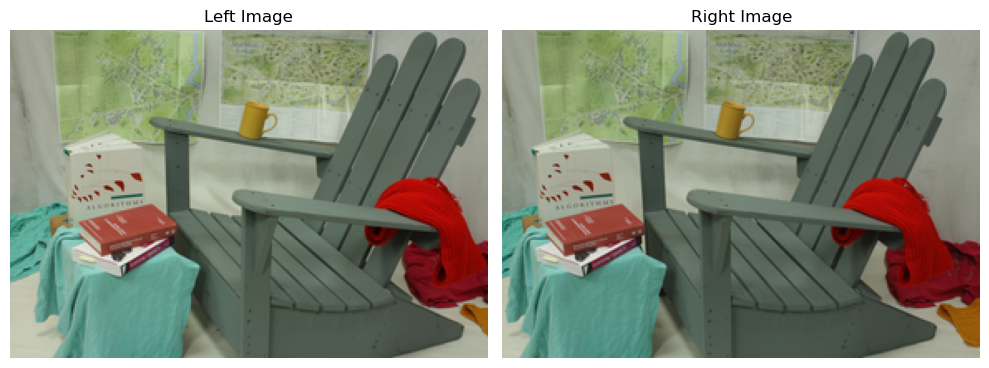

In [27]:
# Visualize left and right images
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 10))

ax1.imshow(im_left)
ax1.set_title('Left Image')
ax1.axis('off')

ax2.imshow(im_right)
ax2.set_title('Right Image')
ax2.axis('off')

plt.tight_layout()
plt.show()

## Convex error profile

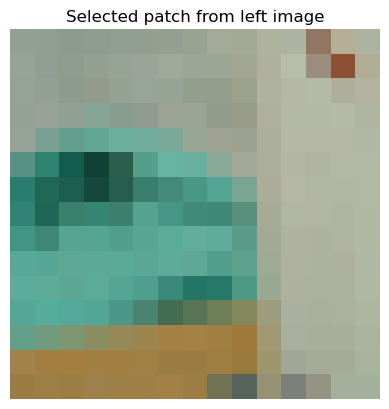

In [28]:
# Extract a patch of interest from the left image
patch_size = 15
x_idx, y_idx = (100, 25)  # TODO: adjust coordinates based on image texture
patch_left_img = torch.tensor(im_left[x_idx:x_idx+patch_size, y_idx:y_idx+patch_size, :])

plt.imshow(patch_left_img)
plt.title("Selected patch from left image")
plt.axis('off')
plt.show()

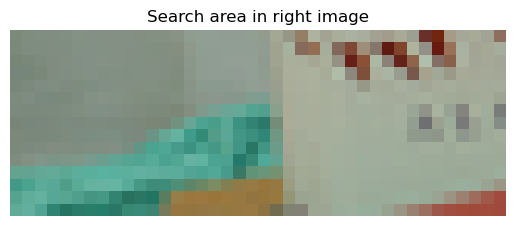

In [29]:
# Define the search area in the right image
# max_search_bound = 0  # might need adjustment based on your (x_idx, y_idx)
max_search_bound = 50  # might need adjustment based on your (x_idx, y_idx)

search_area_right_img = torch.tensor(
    im_right[x_idx:x_idx+patch_size, max(0, y_idx-max_search_bound):y_idx+patch_size, :]
)

plt.imshow(search_area_right_img)
plt.title("Search area in right image")
plt.axis('off')
plt.show()

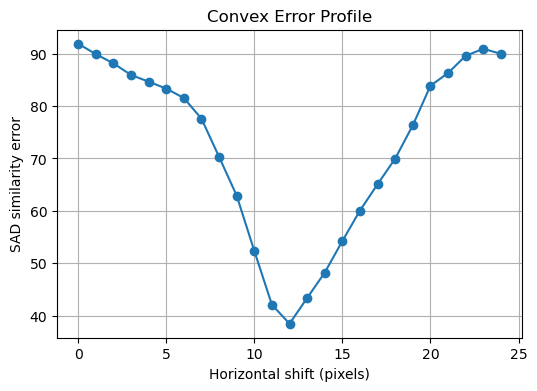

In [30]:
# Compute similarity (SAD) between patch and all horizontal shifts
similarity_vals = np.array([
    sad_similarity_measure(
        patch_left_img,
        search_area_right_img[:, h_idx:h_idx+patch_size, :]
    ).item()
    for h_idx in range(search_area_right_img.shape[1] - patch_size)
])

# Plot convex error profile
plt.figure(figsize=(6, 4))
plt.plot(similarity_vals, '-o')
plt.title("Convex Error Profile")
plt.xlabel("Horizontal shift (pixels)")
plt.ylabel("SAD similarity error")
plt.grid(True)
plt.show()

### Reflection Question 5:
Convex Error Profile: Can you generalize the type of regions that generate a convex error profile?    
**Answer:** Text explanation here 
- Reponse: A convex error profile is generated in areas where a window is unique and there is one clear minimum. For example in the example I chose there is a lot of edges / texture that can give our similarity measures an easy time with finding a match. Because of this when I chose my convex error profile I was looking for a horizontal line that would only show a pattern once.

## Non-Convex error profile

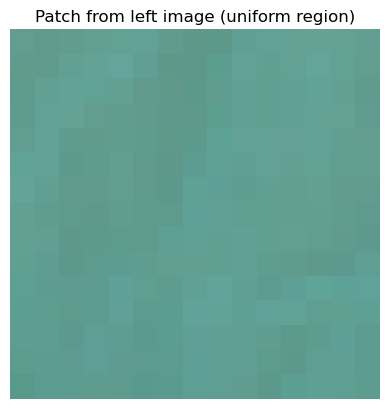

In [31]:
# Extract patch from a uniform region (for non-convex behavior)
patch_size = 15
x_idx, y_idx = (170, 70)  # # TODO: adjust coordinates based on image texture
patch_left_img = torch.tensor(im_left[x_idx:x_idx+patch_size, y_idx:y_idx+patch_size, :])

plt.imshow(patch_left_img)
plt.title("Patch from left image (uniform region)")
plt.axis('off')
plt.show()

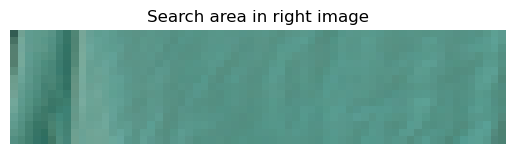

In [32]:
# Define search area in the right image
# max_search_bound = 0 # might need adjustment based on your (x_idx, y_idx)
max_search_bound = 50 # might need adjustment based on your (x_idx, y_idx)

search_area_right_img = torch.tensor(
    im_right[x_idx:x_idx+patch_size, max(0, y_idx-max_search_bound):y_idx+patch_size, :]
)

plt.imshow(search_area_right_img)
plt.title("Search area in right image")
plt.axis('off')
plt.show()

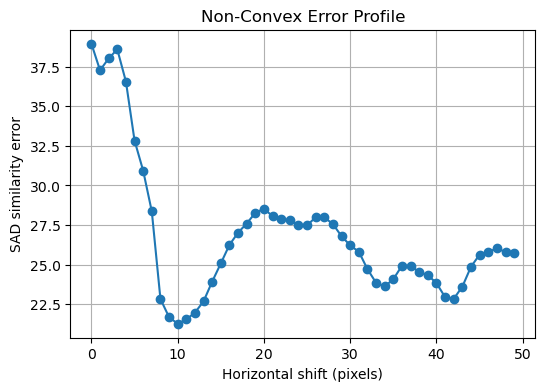

In [33]:
# Compute similarity (SAD) across horizontal shifts for non-convex region
similarity_vals = np.array([
    sad_similarity_measure(
        patch_left_img,
        search_area_right_img[:, h_idx:h_idx+patch_size, :]
    ).item()
    for h_idx in range(search_area_right_img.shape[1] - patch_size)
])

plt.figure(figsize=(6, 4))
plt.plot(similarity_vals, '-o')
plt.title("Non-Convex Error Profile")
plt.xlabel("Horizontal shift (pixels)")
plt.ylabel("SAD similarity error")
plt.grid(True)
plt.show()

### Reflection Question 6:
Non-Convex Error Profile: Can you generalize the type of regions that generate a non-convex error profile?    
**Answer:** Text explanation here
- Response: This comes from cases where the patterns on the scanline aren't unique. For my example I purposelly choose the towel because it has a large region of similar windows on the scan line. In the example I chose there are multiple areas along the towel that give a low similarity error. This is because along that towel there isn't a lot of texture, edges, etc..

# Real life stereo images

## Example 1

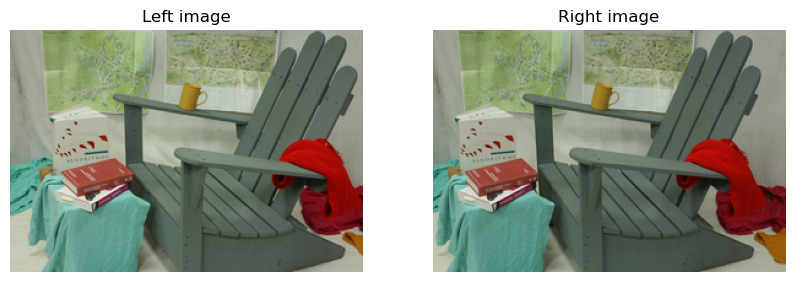

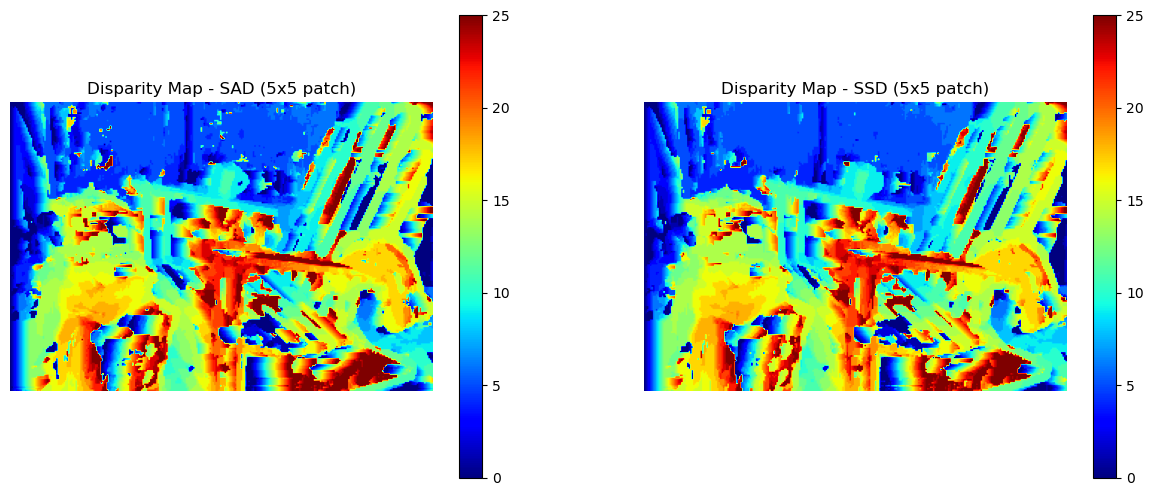

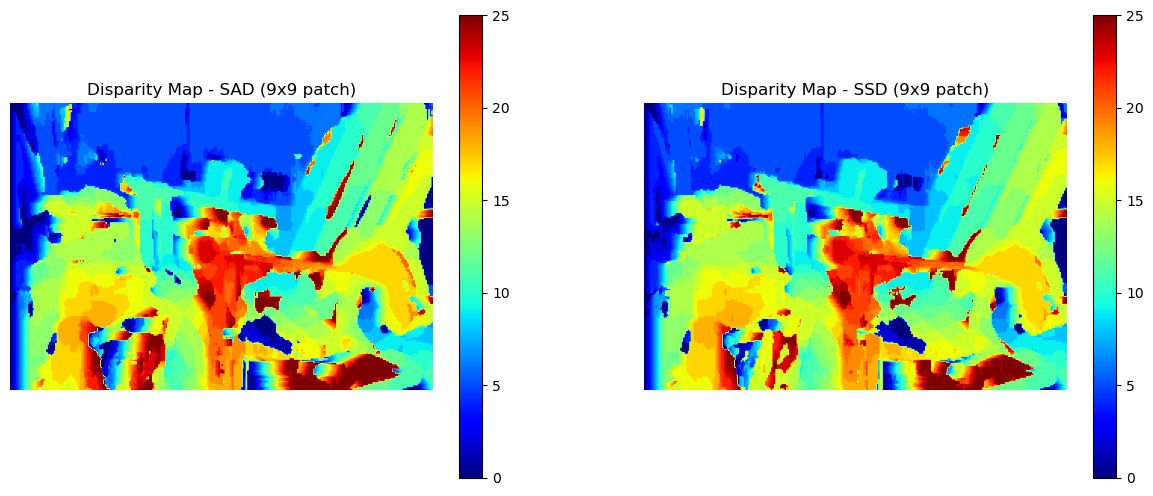

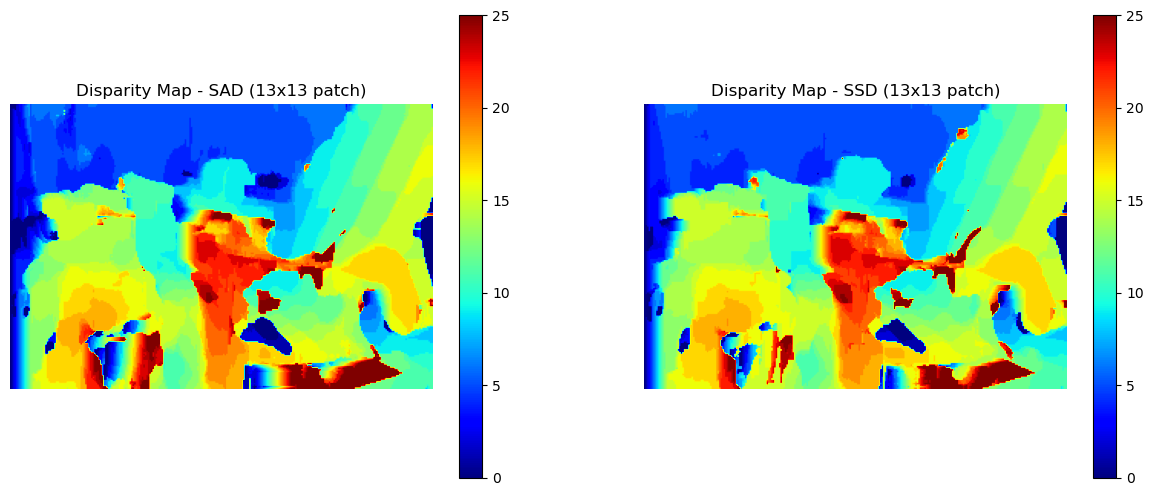

In [34]:
# Visualize disparity maps for real stereo pair (Adirondack)
# Try varying block_size and max_search_bound for best results
stereo_helper_fn(
    torch.tensor(im_left),
    torch.tensor(im_right),
    block_size=[5, 9, 13],
    max_search_bound=25
)

### Reflection Question 7:
Which patch size gives the clearest depth representation? Why?  
**Answer:** Text explanation here  
-Response: The 5x5 patch gives the clearest depth representation. Its a similar thing to what was already explained above. If you window size is too large then your similarity measures stop being helpful. We notice that in this example the results consistently get worse as you continue to increase that patch size.

### Reflection Question 8:
Why does the backrest of the chair appear blocky in the disparity map?  
**Answer:** Text explanation here
-Response: I believe this is because there are multiple different "depths" in a region. For example if we look at the 5x5 patch we realize that although the chair is close whats behind the chair (the things that can be seen through the gap) aren't close.

## Set 2

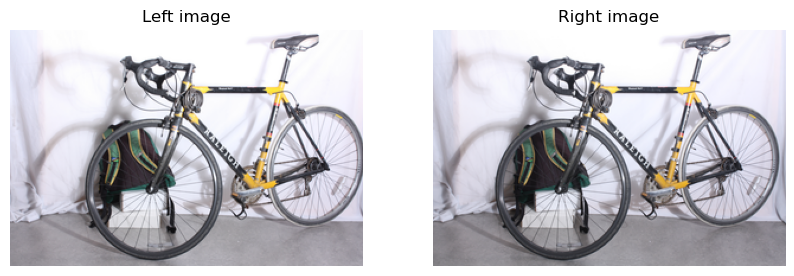

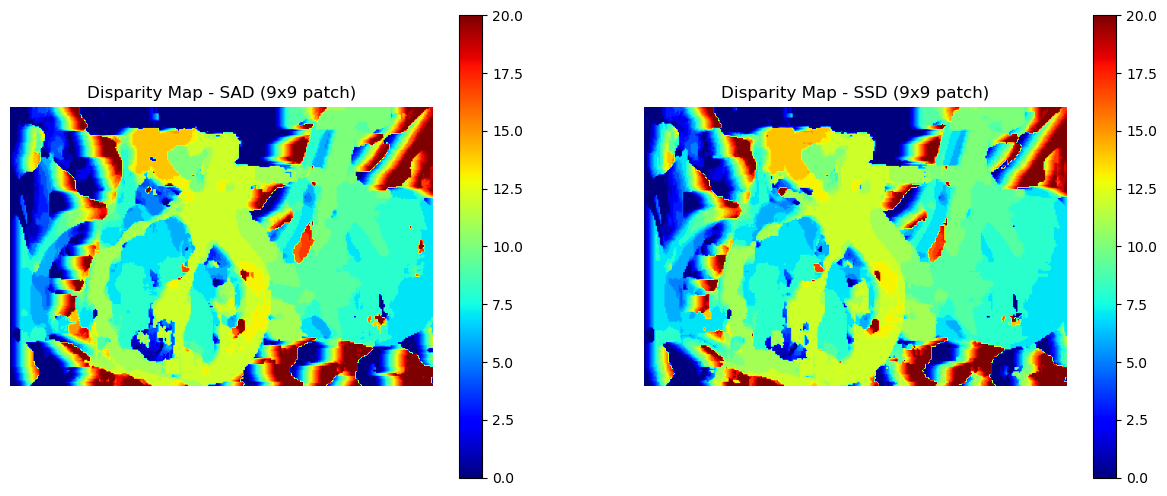

In [ ]:
# =========================================
# Set 2: Bicycle Scene
# =========================================
base_path = '../data/bicycle/'

# Load and downscale to 10% size for faster processing
im_left = PIL_resize(load_image(base_path + 'im_left.png'), (0.1, 0.1))
im_right = PIL_resize(load_image(base_path + 'im_right.png'), (0.1, 0.1))

# Compute and visualize disparity maps
stereo_helper_fn(
    torch.tensor(im_left),
    torch.tensor(im_right),
    block_size=[7],       # Experiment: try 7, 9, 11, 13
    max_search_bound=20
)

After trying all of the block sizes the one that gave me the best results was 7. This is right in line with what has been discussed multiple times thoughout this writeup.

## Set 3

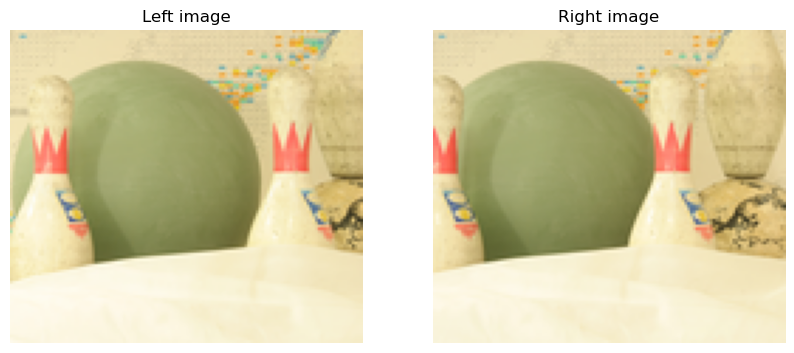

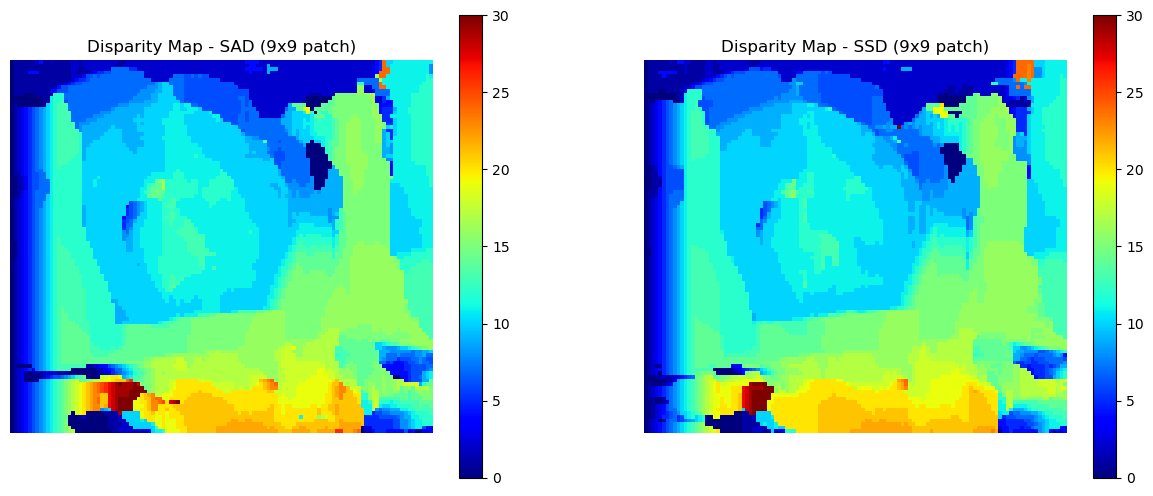

In [38]:
# =========================================
# Set 3: Bowling Scene
# =========================================
base_path = '../data/bowling/'

# Load and downscale to 20% size
im_left = PIL_resize(load_image(base_path + 'im_left.png'), (0.2, 0.2))
im_right = PIL_resize(load_image(base_path + 'im_right.png'), (0.2, 0.2))

# Compute and visualize disparity maps
stereo_helper_fn(
    torch.tensor(im_left),
    torch.tensor(im_right),
    block_size=[9],
    max_search_bound=30
)

### Reflection Question 9:
Bowling Scene (Set 3): Observe the head of the right-side bowling pin. What do you notice in the disparity map?  
What visual property might explain this behavior?  
**Answer:** Text solution here  
- Repsonse: If we look at the original image we notice that the bowling right bowling pin is very noisy. The results in this area aren't very helpful or reliable. This is because of the lack of texture and constrast present on the head of the bowling pin. We notice that the bowling pin head almost blends into the background.

## Set 4

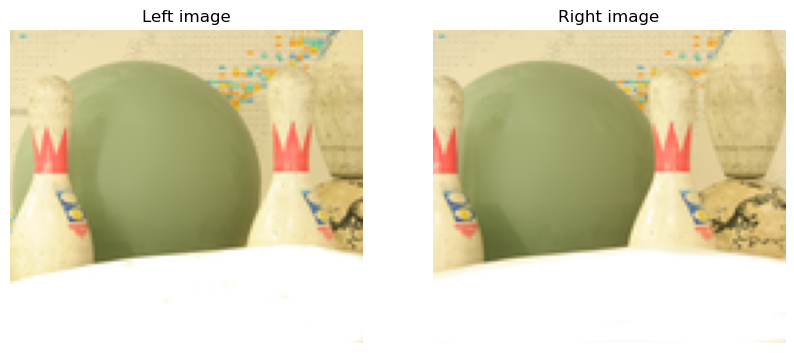

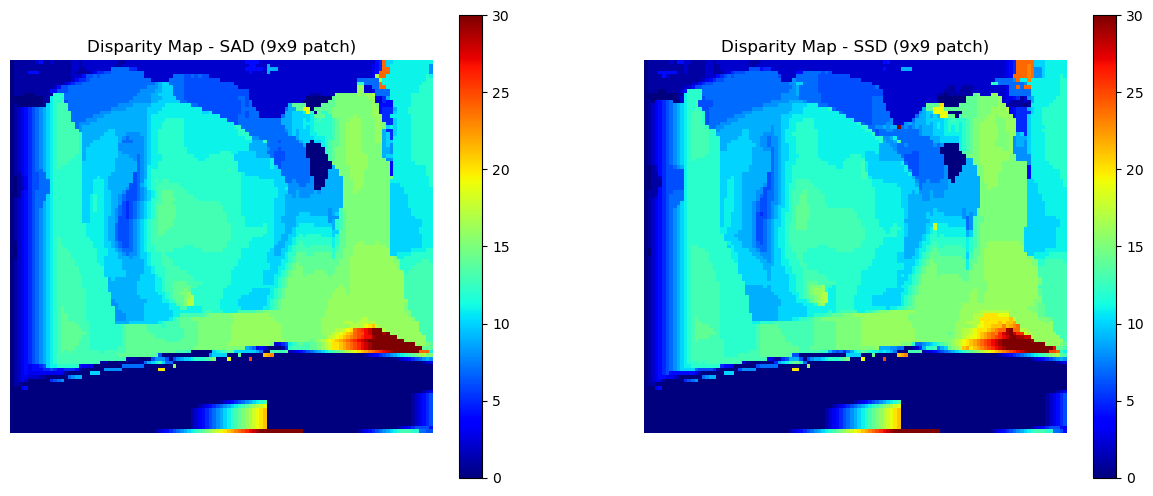

In [39]:
# =========================================
# Set 4: Bowling (Manipulated Scene)
# =========================================
base_path = '../data/bowling2/'

# Load and resize to 20% scale
im_left = PIL_resize(load_image(base_path + 'im_left.png'), (0.2, 0.2))
im_right = PIL_resize(load_image(base_path + 'im_right.png'), (0.2, 0.2))

# Visualize disparity map
stereo_helper_fn(
    torch.tensor(im_left),
    torch.tensor(im_right),
    block_size=[9],
    max_search_bound=30
)

### Reflection Question 10:
Manipulated Bowling Scene (Set 4): Why does the disparity drop to zero at the bottom of the image and around the green bowling ball?  
**Answer:** Text explanation here  
- Response: From our previous analysis we know that a low disparity means the region is far away from the camera. We can basically find a match anywhere in the bottom section because it is textureless. The disparity map believes there is almost no disparity between patch 1 and patch 2 because the patch can match without hardly any shift.

## Set 5

In [ ]:
# =========================================
# Set 5: Flowers Scene
# =========================================
base_path = '../data/flowers/'

# Load and downscale to 10% for faster computation
im_left = PIL_resize(load_image(base_path + 'im_left.png'), (0.10, 0.10))
im_right = PIL_resize(load_image(base_path + 'im_right.png'), (0.10, 0.10))

# Compute and visualize disparity maps
stereo_helper_fn(
    torch.tensor(im_left),
    torch.tensor(im_right),
    block_size=[9],
    max_search_bound=50
)

**Observations**: (these observations do not go in the report. These are for your understanding).

(These are not part of the report but are meant to guide your interpretation.)

1.	Notice the difference in disparity between the flower at the back and its shadow on the wall.
- Response: We notice that the flowers shadow has a lower disparity. This is expected and correct. Stereo notices that the shadow is further away then the object itself

2.	Identify the zero-disparity region at the center of the house structure.
- Response: This is once again due to a lack of texture.

3.	Observe how smooth the disparity is across the couch — what does this tell you about texture and surface uniformity?
- Response: The disparity is smooth because there are unique patterns and texture. We are more likely to get surface uniformity in our disparity map if something is textured. 

## Set 6

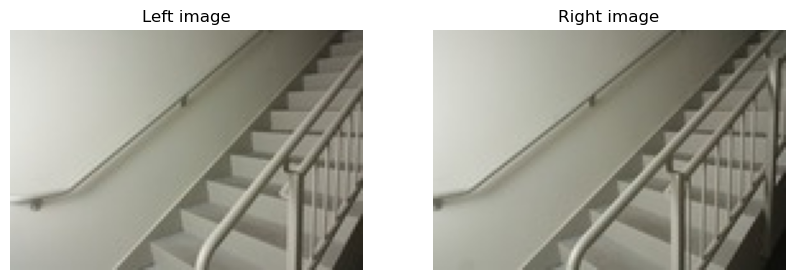

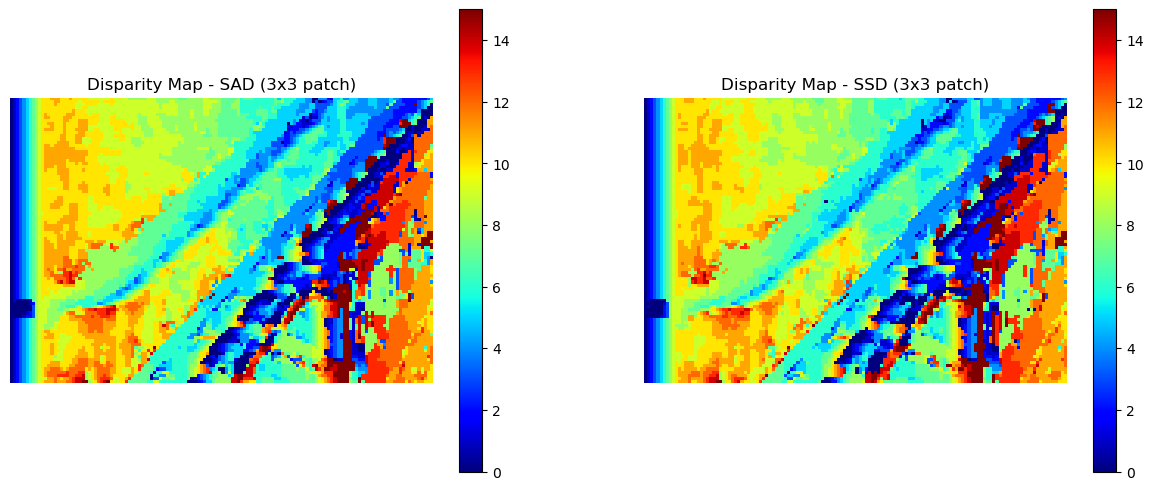

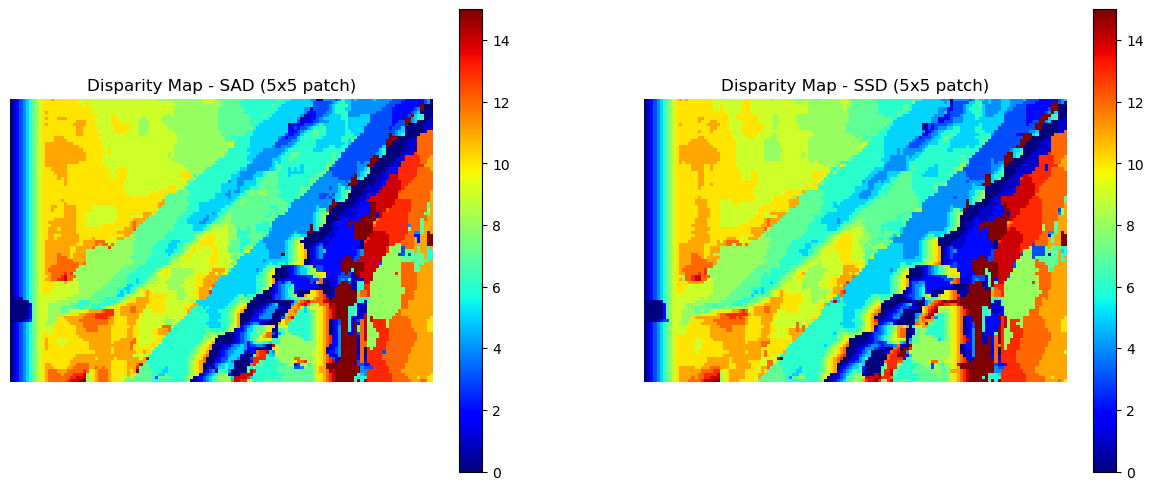

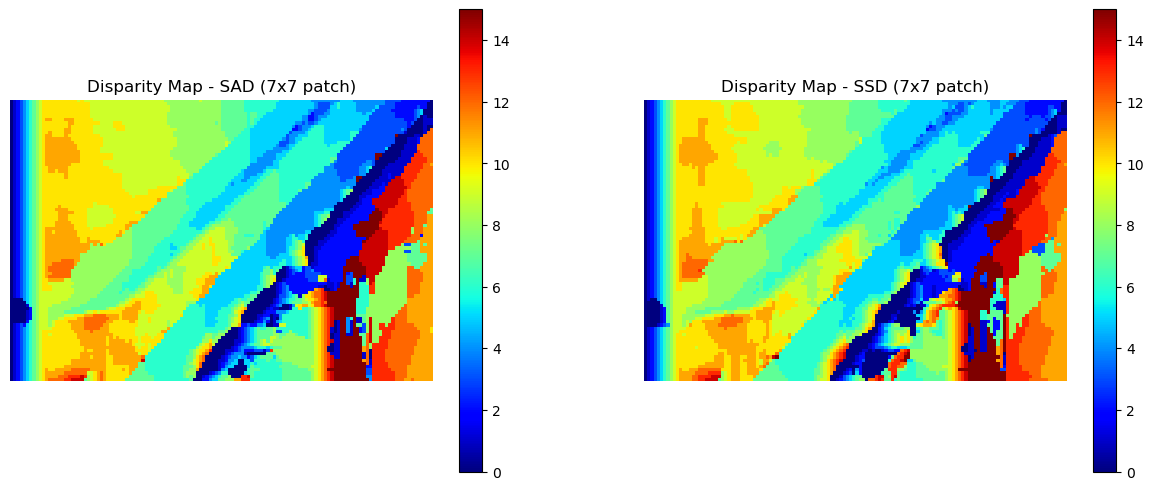

In [41]:
# =========================================
# Set 6: Stairs Scene
# =========================================
base_path = '../data/stairs/'

# Load and keep full resolution (1x scale)
im_left = PIL_resize(load_image(base_path + 'im_left.jpg'), (1, 1))
im_right = PIL_resize(load_image(base_path + 'im_right.jpg'), (1, 1))

# Compute and visualize disparity maps
stereo_helper_fn(
    torch.tensor(im_left),
    torch.tensor(im_right),
    block_size=[3, 5, 7],
    max_search_bound=15
)

### Reflection Question 11:
Why are we able to see a gradual shift in disparity values along the wall?  
**Answer:** Text explanation here  
- Response: Even though we don't have high contrast here because of the fact that when we search we search horizontally we are still able to find matching patterns well. On each horizontal scan line we will only run into one portion of the hand rail. If the rail was horizontal as well we would have a lot more problems.

### Reflection Question 12: 
What is the effect of block size on your ability to see the stair-like structure in the disparity map?  
**Answer:** Text explanation here
- Response: The higher we increase block size the more difficult it becomes to see the stair-like structure. This is because of the reasons already discussed. As we increase the block size our disparity map becomes noisier because our similarity measures struggle.

# Smoothing

One issue with the results from is that they aren't very smooth. Pixels next to each other on the same surface can have vastly different disparities, making the results look very noisy and patchy in some areas. Intuitively, pixels next to each other should have a smooth transition in disparity(unless at an object boundary or occlusion).
In this section, we try to improve our results. One way of doing this is through the use of a smoothing constraint. The smoothing method we use is called Semi-Global Matching(SGM) or Semi-Global Block Matching. Before, we picked the disparity for a pixel based on the minimum matching cost of the block using some metric(SSD or SAD). The basic idea of SGM is to penalize pixels with a disparity that's very different than their neighbors by adding a penalty term on top of the matching cost term. SGM tries to minimize the global(over the entire image) energy function
\begin{equation*}
E(D) \leq \sum_{p} (C(p, D_p) + \sum_{q} PT(|D_p - D_q|))
\end{equation*}
C(p,D_p) is the matching cost for a pixel with disparity D_p, q is a neighboring pixel, and PT is some penalty function penalizing the difference in disparities.
You can read more about how this method works and is optimized here:
https://elib.dlr.de/73119/1/180Hirschmueller.pdf
and
https://pdfs.semanticscholar.org/bcd8/4d8bd864ff903e3fe5b91bed3f2eedacc324.pdf

Before we implement the smoothing algorithm, we need to implement a function which computes the **cost volume**. We have already written code to compute disparity map. We will extend that code to compute the cost volume. Instead of taking the argmin of the similarity error profile, we will store the tensor of error profile at each pixel location along the third dimension.

If we have an input image of dimension (H,W,C) and max search bound of D, the cost_volume will be a tensor of dimension (H,W,D). The cost volumne at (i,j) pixel is the error profile obtained for the patch in the left image centered at (i,j).

Implement this part as function ```calculate_cost_volume``` in ```disparity_map.py```. Feel free to reuse any code you have written till now.

In [46]:
from unit_tests.test_disparity_map import (
  test_calculate_cost_volume
)

print('Testing for calculate_cost_volume', verify(test_calculate_cost_volume))

Testing for calculate_cost_volume "Correct"



Starting cost computation...

Starting aggregation computation...
	Processing paths east and west...	(done in 2.57 s)
	Processing paths south-east and north-west...	(done in 2.59 s)
	Processing paths south and north...	(done in 2.60 s)
	Processing paths south-west and north-east...	(done in 2.60 s)

Selecting best disparities...

Done


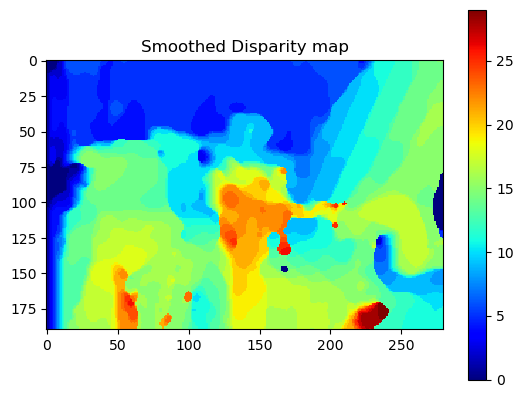

In [47]:
# Load the image
from semiglobalmatching.sgm import sgm
from scipy import ndimage
from proj4_code.similarity_measures import sad_similarity_measure, ssd_similarity_measure

#you can change the path to try other pairs, but you may need to fix the scaling per pair
base_path = '../data/adirondack/'
im_left = PIL_resize(load_image(base_path + 'im_left.png'), (0.10, 0.10))
im_right = PIL_resize(load_image(base_path + 'im_right.png'), (0.10, 0.10))

#calculates the disparity map with SGM, the last argument is max disparity to consider
disparity_map = sgm(im_left,im_right, "result", 30, sad_similarity_measure, 9)
result = ndimage.median_filter(disparity_map, size=5)
plt.figure()
plt.imshow(result, cmap='jet', interpolation='nearest')
plt.title('Smoothed Disparity map')
plt.colorbar()
plt.show()

### Reflection Question 13:
Compare SGM (smoothing) result vs disparity map of the chair image without smoothing.  
**Answer:** Text explanation here
- Response: We notice that the disparity map is significantly less messy but we also noitce that we lose most of the shape of our objects. Edges are basically nonexistent. This could be helpful depending on our application and what type of accuracy we would need.

### Reflection Question 14:
On what regions of the image does smoothing perform better, and why?  
**Answer:** Text explanation here  
- Response: It preforms better and areas that have high frequency changes. Because we smooth first we remove a lot of our high frequency changes.

### Reflection Question 15:
On what regions of the image does smoothing perform worse, and why?  
**Answer:** Text explanation here  
- Response: This was already detailed above but its going to preform worse around edges and hard lines. This is because like stated previously we are smoothing out our high frequency changes before calculating our disparity map.

### Reflection Question 16:
Would smoothing still work for images with both horizontal and vertical shift? Explain why or why not.  
**Answer:** Text explanation here
- Response: I don't believe that smoothing would work for images with both horizontal and vertical shift. Because of the smoothing I believe we would start getting matches where matches didn't actually exist and the result would be unreliable.

### Reflection Question 17: Extra Credit
Try the smoothing method with your own image pair.  
If good results, explain why your pair is “easy.”  
If bad results, explain why your pair is “hard.”  
**Answer:** Insert your own left and right images here along with text explanation here

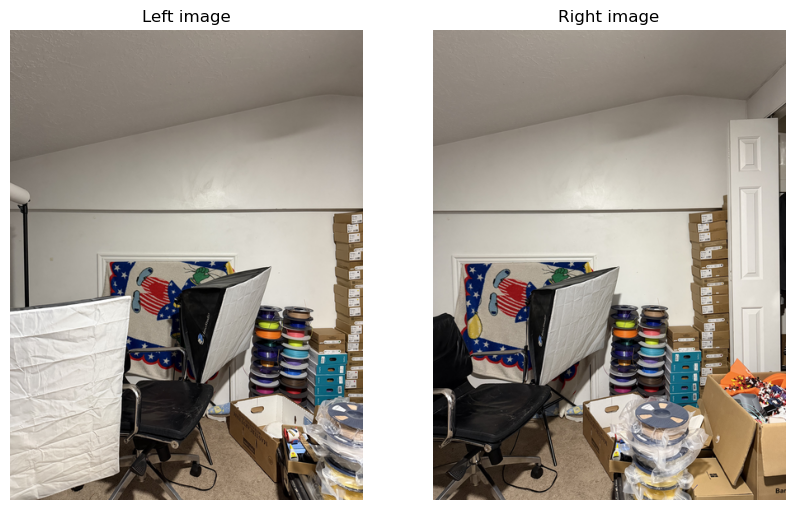


Starting cost computation...

Starting aggregation computation...
	Processing paths east and west...	(done in 10.62 s)
	Processing paths south-east and north-west...	(done in 10.82 s)
	Processing paths south and north...	(done in 10.76 s)
	Processing paths south-west and north-east...	(done in 10.92 s)

Selecting best disparities...

Done


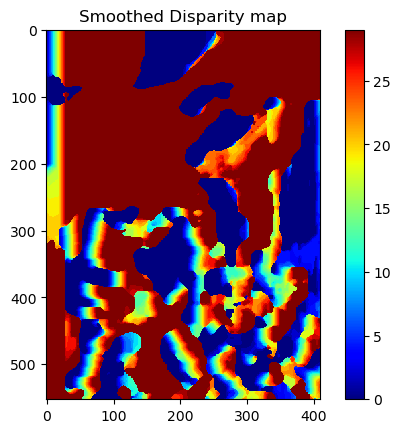

In [52]:
# Load the image
from semiglobalmatching.sgm import sgm
from scipy import ndimage
from proj4_code.similarity_measures import sad_similarity_measure, ssd_similarity_measure

#you can change the path to try other pairs, but you may need to fix the scaling per pair
base_path = '../data/my_images/'
im_left = PIL_resize(load_image(base_path + 'im_left.png'), (0.10, 0.10))
im_right = PIL_resize(load_image(base_path + 'im_right.png'), (0.10, 0.10))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 10))

ax1.imshow(im_left, interpolation=None)
ax1.title.set_text('Left image')
ax1.autoscale(False)
ax1.set_axis_off()

ax2.imshow(im_right, interpolation=None)
ax2.title.set_text('Right image')
ax2.autoscale(False)
ax2.set_axis_off()

plt.show()

#calculates the disparity map with SGM, the last argument is max disparity to consider
disparity_map = sgm(im_left,im_right, "result", 30, sad_similarity_measure, 18)
result = ndimage.median_filter(disparity_map, size=5)
plt.figure()
plt.imshow(result, cmap='jet', interpolation='nearest')
plt.title('Smoothed Disparity map')
plt.colorbar()
plt.show()

- Response: The results I got were quite bad and very noisy. I can see some valid depth information but the majority of it isn't great. I believe that this is because I tried to take the images carefuly to make them be as rectified as possible but because of human error I don't believe these images are fully rectified. We disucssed in class how much of an issue not satsifying this property could be and I believe that is what we are seeing here